In [50]:
#import the libraries

!pip install torch torchvision

In [51]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
import numpy as np
from tqdm import tqdm 

In [52]:
class SingleRNN(nn.Module):
    def __init__(self,n_inputs,n_neurons):
        super(SingleRNN,self).__init__()
        
        self.Wx=torch.randn(n_inputs,n_neurons) # 4*1
        self.Wy=torch.randn(n_neurons,n_neurons) # 1*1
        
        self.b = torch.zeros(1,n_neurons) # 1*4
        
    def forward(self,X0,X1):
        self.Y0=torch.tanh(torch.mm(X0,self.Wx)+self.b) # 4*1
        self.Y1=torch.tanh(torch.mm(self.Y0,self.Wy)+torch.mm(X1,self.Wx)+self.b) #4*1
        
        return self.Y0,self.Y1

In [53]:
N_INPUTS = 4
N_NEURONS = 1

X0_batch = torch.tensor([[0,1,2,0],[3,4,5,0],[6,7,8,0],[9,0,1,0]],dtype=torch.float)
X1_batch = torch.tensor([[9,8,7,0],[0,0,0,0],[6,5,4,0],[3,2,1,0]],dtype=torch.float)

model=SingleRNN(N_INPUTS,N_NEURONS)

Y0_val,Y1_val = model(X0_batch,X1_batch)

In [54]:
print("Y0_val:",Y0_val)
print("Y1_val:",Y1_val)

Y0_val: tensor([[0.6068],
        [1.0000],
        [1.0000],
        [0.9999]])
Y1_val: tensor([[ 1.0000],
        [-0.1971],
        [ 1.0000],
        [ 0.9988]])


In [55]:
class BasicRNN(nn.Module):
    def __init__(self,n_inputs,n_neurons):
        super(BasicRNN,self).__init__()
        
        self.Wx=torch.randn(n_inputs,n_neurons) # 4*1
        self.Wy=torch.randn(n_neurons,n_neurons) # 1*1
        
        self.b = torch.zeros(1,n_neurons) # 1*4
        
    def forward(self,X0,X1):
        self.Y0=torch.tanh(torch.mm(X0,self.Wx)+self.b) # 4*1
        self.Y1=torch.tanh(torch.mm(self.Y0,self.Wy)+torch.mm(X1,self.Wx)+self.b) #4*1
        
        return self.Y0,self.Y1

In [56]:
N_INPUTS = 3
N_NEURONS = 5

X0_batch = torch.tensor([[0,1,2],[3,4,5],[6,7,8],[9,0,1]],dtype=torch.float)
X1_batch = torch.tensor([[9,8,7],[0,0,0],[6,5,4],[3,2,1]],dtype=torch.float)

model=SingleRNN(N_INPUTS,N_NEURONS)

Y0_val,Y1_val = model(X0_batch,X1_batch)

In [57]:
print("Y0_val:",Y0_val)
print("Y1_val:",Y1_val)

Y0_val: tensor([[ 0.8081, -0.8628,  0.9996,  0.9316,  0.9991],
        [ 1.0000,  0.9584,  1.0000,  1.0000,  1.0000],
        [ 1.0000,  0.9999,  1.0000,  1.0000,  1.0000],
        [ 0.9900,  1.0000, -1.0000, -0.4285, -0.9961]])
Y1_val: tensor([[ 1.0000,  1.0000,  0.9705,  1.0000,  1.0000],
        [ 0.7650, -0.8336, -0.9910,  0.9397, -0.9949],
        [ 1.0000,  1.0000, -0.9668,  1.0000,  0.9999],
        [ 0.9770,  0.1125, -0.9842, -0.6902,  0.9940]])


In [58]:
rnn = nn.RNNCell(3,5)

X_batch = torch.tensor([[[0,1,2],[3,4,5],[6,7,8],[9,0,1]],
                        [[9,8,7],[0,0,0],[6,5,4],[3,2,1]]],dtype=torch.float)


hx=torch.randn(4,5)

output = []
for i in range(2):
    hx=rnn(X_batch[i],hx)
    output.append(hx)
    
print(output)

[tensor([[-0.1879, -0.6366, -0.5776,  0.6137,  0.1116],
        [ 0.1505, -0.9724, -0.9868,  0.9918, -0.1063],
        [ 0.0591, -0.9657, -0.9998,  0.9999, -0.8893],
        [ 0.9964, -0.9785, -0.9984,  0.9992,  0.1743]],
       grad_fn=<TanhBackward0>), tensor([[ 0.5859, -0.9634, -1.0000,  1.0000, -0.9210],
        [-0.1562,  0.4531,  0.0773,  0.1215,  0.2518],
        [ 0.2093, -0.5402, -0.9996,  0.9980, -0.6211],
        [ 0.3028, -0.3604, -0.8874,  0.8971,  0.0661]],
       grad_fn=<TanhBackward0>)]


In [59]:
import torchvision
import torchvision.transforms as transforms

In [60]:
BATCH_SIZE = 64

# list all transformations
transform = transforms.Compose(
    [transforms.ToTensor()])
# download and load training dataset
trainset = torchvision.datasets.MNIST(root='./data', train=True,download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE,shuffle=True, num_workers=0)
# download and load testing dataset

testset = torchvision.datasets.MNIST(root='./data', train=False,download=True, transform=transform)

testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE,shuffle=False, num_workers=0)

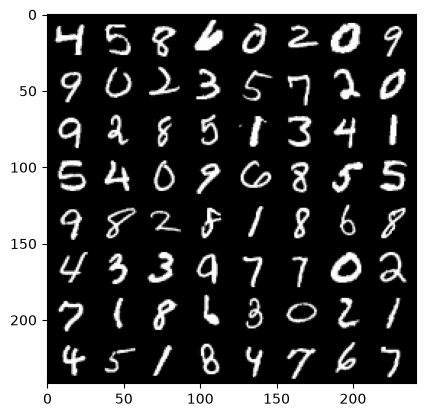

In [61]:
import matplotlib.pyplot as plt
import numpy as np
# functions to show an image
def imshow(img):
    #img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
# get some random training images
data_iter = iter(trainloader)
images, labels = next(data_iter)
# show images
imshow(torchvision.utils.make_grid(images))

In [62]:
# parameters
N_STEPS=28
N_INPUTS = 28
N_NEURONS = 150
N_OUTPUTS = 10
N_EPHOCS = 10

In [63]:
class ImageRNN(nn.Module):
    def __init__(self, batch_size, n_steps, n_inputs, n_neurons, n_outputs):
        super(ImageRNN, self).__init__()

        self.n_neurons = n_neurons
        self.batch_size = batch_size
        self.n_steps = n_steps
        self.n_inputs = n_inputs
        self.n_outputs = n_outputs

        self.basic_rnn = nn.RNN(self.n_inputs, self.n_neurons)

        self.FC = nn.Linear(self.n_neurons, self.n_outputs)

    def init_hidden(self,):
        # (num_layers, batch_size, n_neurons)
        return (torch.zeros(1, self.batch_size, self.n_neurons))

    def forward(self, X):
        # transforms X to dimensions: n_steps X batch_size X n_inputs
        X = X.permute(1, 0, 2)
        self.batch_size = X.size(1)
        self.hidden = self.init_hidden()
        # lstm_out => n_steps, batch_size, n_neurons (hidden states for each time step)
        # self.hidden => 1, batch_size, n_neurons (final state from each lstm_out)
        lstm_out, self.hidden = self.basic_rnn(X, self.hidden)
        out = self.FC(self.hidden)
        return out.view(-1, self.n_outputs) # batch_size X n_output

In [64]:
dataiter = iter(trainloader)
images, labels = next(dataiter)
model = ImageRNN(BATCH_SIZE, N_STEPS, N_INPUTS, N_NEURONS, N_OUTPUTS)
logits = model(images.view(-1, 28,28))
print(logits[0:10])

tensor([[ 0.0198,  0.0047,  0.0635, -0.0752, -0.0353,  0.0235, -0.0367,  0.0495,
         -0.0495, -0.0028],
        [ 0.0131, -0.0049,  0.0635, -0.1197, -0.0495,  0.0265, -0.0486,  0.0387,
         -0.0504, -0.0155],
        [ 0.0174, -0.0196,  0.0448, -0.0936, -0.0441,  0.0240, -0.0538,  0.0521,
         -0.0415, -0.0138],
        [ 0.0234,  0.0133,  0.0707, -0.0951, -0.0337,  0.0296, -0.0477,  0.0388,
         -0.0464,  0.0009],
        [ 0.0181, -0.0165,  0.0499, -0.1121, -0.0365,  0.0266, -0.0455,  0.0409,
         -0.0482, -0.0118],
        [ 0.0197, -0.0184,  0.0729, -0.1064, -0.0238,  0.0168, -0.0473,  0.0420,
         -0.0437, -0.0330],
        [ 0.0167, -0.0171,  0.0507, -0.1009, -0.0453,  0.0286, -0.0477,  0.0395,
         -0.0520, -0.0189],
        [ 0.0171, -0.0152,  0.0568, -0.0974, -0.0358,  0.0241, -0.0522,  0.0523,
         -0.0467, -0.0091],
        [ 0.0091, -0.0050,  0.0846, -0.1178,  0.0051,  0.0109, -0.0279,  0.0673,
         -0.0590, -0.0120],
        [ 0.0218, -

In [65]:
import torch.optim as optim
# Device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# Model instance
model = ImageRNN(BATCH_SIZE, N_STEPS, N_INPUTS, N_NEURONS, N_OUTPUTS)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
def get_accuracy(logit, target, batch_size):
    ''' Obtain accuracy for training round '''
    corrects = (torch.max(logit, 1)[1].view(target.size()).data == target.data).sum()
    accuracy = 100.0 * corrects/batch_size
    return accuracy.item()

In [66]:
for epoch in range(N_EPHOCS):  # loop over the dataset multiple times
    train_running_loss = 0.0
    train_acc = 0.0
    model.train()
    # TRAINING ROUND
    for i, data in enumerate(trainloader):
         # zero the parameter gradients
        optimizer.zero_grad()
        # reset hidden states
        model.hidden = model.init_hidden()
        # get the inputs
        inputs, labels = data
        inputs = inputs.view(-1, 28,28)
        # forward + backward + optimize
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_running_loss += loss.detach().item()
        train_acc += get_accuracy(outputs, labels, BATCH_SIZE)
    model.eval()
    print('Epoch:  %d | Loss: %.4f | Train Accuracy: %.2f'
          %(epoch, train_running_loss / i, train_acc/i))

Epoch:  0 | Loss: 0.6355 | Train Accuracy: 79.78
Epoch:  1 | Loss: 0.2845 | Train Accuracy: 91.65
Epoch:  2 | Loss: 0.2254 | Train Accuracy: 93.49
Epoch:  3 | Loss: 0.1830 | Train Accuracy: 94.82
Epoch:  4 | Loss: 0.1565 | Train Accuracy: 95.61
Epoch:  5 | Loss: 0.1419 | Train Accuracy: 96.01
Epoch:  6 | Loss: 0.1358 | Train Accuracy: 96.18
Epoch:  7 | Loss: 0.1346 | Train Accuracy: 96.19
Epoch:  8 | Loss: 0.1234 | Train Accuracy: 96.58
Epoch:  9 | Loss: 0.1207 | Train Accuracy: 96.64


In [67]:
test_acc = 0.0
for i, data in enumerate(testloader, 0):
    inputs, labels = data
    inputs = inputs.view(-1, 28,28)
    outputs = model(inputs)
    test_acc += get_accuracy(outputs, labels, BATCH_SIZE)
print('Test Accuracy: %.2f' % (test_acc / i))

Test Accuracy: 95.33
